# Clockwork-Vol — a quantitative teardown 🔬
### Periodogram · AR(1) red-noise envelope · period stability · walk-forward · random-phase null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fixed-clock: Not supported](https://img.shields.io/badge/Fixed--clock-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* Thesis: the VIX's claimed 40/80-session cycles **do not exceed the AR(1) red-noise envelope**, their period is **unstable**, and the adaptive walk-forward projection carries **no forecast skill** over a random-phase null — one fixed-80d fragment survives its own null raw and is weighed, and bounded, in beat 7.

> ⚠️ **Not investment advice.** Executed on the **synthetic series** (a real injected cycle), where the detector works — this validates the machinery end-to-end; the real verdict is quoted from [`../docs/results.md`](../docs/results.md) (`examples/verify_real.py`). Methods: FFT periodogram (detrended, split-cosine tapered), AR(1) surrogate envelope, rolling period stability, random-phase walk-forward — see [`../docs/references.md`](../docs/references.md). Fixed seeds; no network.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (vix_cycles/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from vix_cycles import data, spectral, cycles, backtest, robustness

# Offline synthetic log-VIX: a KNOWN fixed cycle (80d & 40d) hidden in AR(1) red noise. This
# is where the detector SHOULD work — so it validates the machinery. The real verdict (the
# VIX, where it does NOT) is in ../docs/results.md via verify_real.py.
series, injected = data.synthetic_cycle(seed=0)
print(f"{len(series)} sessions, injected cycles {[round(c.period) for c in injected]} (a real clock, by construction)")


4000 sessions, injected cycles [80, 40] (a real clock, by construction)


## 1 · The claim, as a testable hypothesis

H₁: the log-VIX periodogram has a peak at P∈{40, 80} sessions that **exceeds the (1−α) AR(1) red-noise quantile**; the period is **stable** across windows; and a fixed-period projection has **out-of-sample direction skill > ½**, beating a random-phase null.
H₀: the VIX is **red noise** (AR(1), persistence ρ) plus mean reversion — its periodogram peaks are the broad, tall, *random* peaks autocorrelation manufactures, and carry no forward information.

In [2]:
env = spectral.red_noise_envelope(series, n_sim=800, seed=0)
print('fitted AR(1) rho:', round(env['rho'],3))
print('detection recall vs injected cycles:', robustness.detection_recall(env, injected, q=0.99))
pd.DataFrame(robustness.red_noise_pvalues(series, targets=(40.,80.), n_sim=800))

fitted AR(1) rho: 0.986
detection recall vs injected cycles: 1.0


,data_peak_power,p_value
target_period,,
40.0000,7.5542,0.0012
80.0000,27.6545,0.0012


## 3–4 · The periodogram against the red-noise envelope

The core picture: data spectrum vs the 95/99% envelope of AR(1) surrogates. A real cycle pokes above; a phantom hides inside. On the synthetic the injected periods clear it — on the VIX (results.md) they don't.

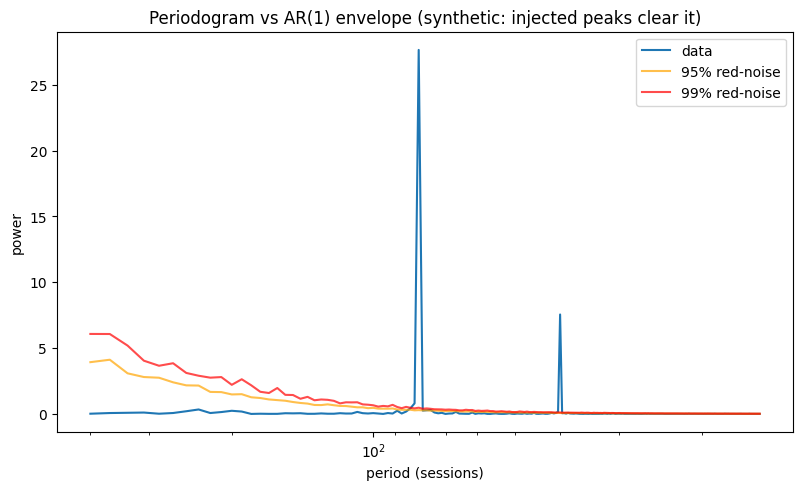

In [3]:
periods, power = spectral.periodogram(series)
m = (periods>=15)&(periods<=400)
plt.semilogx(periods[m], power[m], label='data')
for q,c in [(0.95,'orange'),(0.99,'red')]:
    plt.semilogx(env['periods'][m[:len(env['periods'])]], env['envelope'][q][m[:len(env['periods'])]], c, alpha=.7, label=f'{int(q*100)}% red-noise')
plt.gca().invert_xaxis(); plt.xlabel('period (sessions)'); plt.ylabel('power')
plt.title('Periodogram vs AR(1) envelope (synthetic: injected peaks clear it)'); plt.legend(); plt.show()

## 4 · Period stability — a clock, or a curve-fit?

Rolling the dominant in-band period: near-constant on the synthetic (a true clock), wandering on the VIX (results.md). The drift *is* the verdict — a cycle you must re-tune every quarter isn't a fixed cycle.

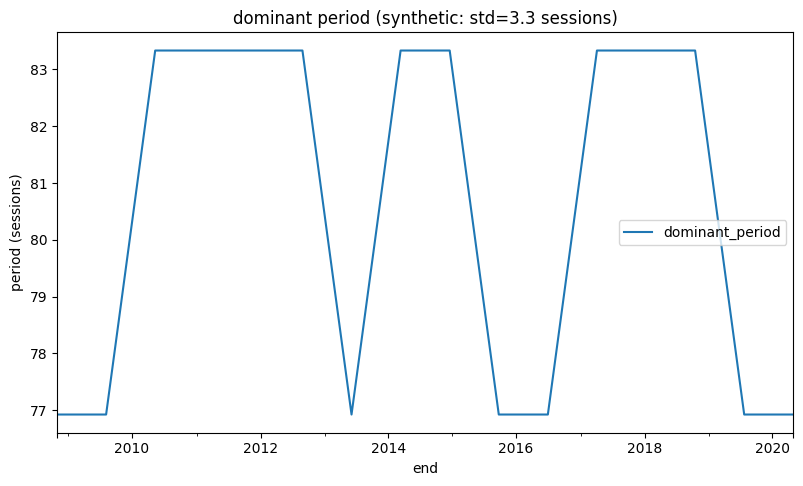

In [4]:
stab = robustness.period_stability(series, band=(20,200), window=1000, step=200)
stab.plot(title=f"dominant period (synthetic: std={stab['dominant_period'].std():.1f} sessions)")
plt.ylabel('period (sessions)'); plt.show()

## 4 · Walk-forward forecast skill vs the random-phase null

The decisive out-of-sample test: fit period+phase on the past, project the next-horizon direction, score vs a null that keeps period & amplitude but scrambles phase. Skill ≈ null ⇒ the timing carries nothing. Synthetic clears it; VIX (results.md) does not.

In [5]:
skill = backtest.oos_direction_skill(series, band=(20,200), horizon=20, min_train=750, n_null=500, seed=0)
print({k: (round(v,4) if isinstance(v,float) else v) for k,v in skill.items()})

{'skill': 0.8947, 'n_calls': 323, 'null_mean': 0.4998, 'null_std': 0.221, 'p_value': 0.0419, 'horizon': 20, 'median_period': 80.0}


## 5–6 · Verdict & the trade

**Signal `NONE`**, **Tradability `MIRAGE`** (results.md). The tradeable expression — long the S&P for the sessions the VIX cycle is projected to fall — is scored against buy-and-hold *and* the random-phase null, with a bootstrap Sharpe CI. Run here as the **positive control**: the toy index below is driven tick-for-tick by the planted cycle's falls, so the harness must bank it (it does — the P&L rule reads the fitted cycle's *one-session* projected slope; a slope read h sessions ahead would lag the cycle by (h−1)/2 sessions and lose even this rigged game). Note the null p95: on a series with a *real* cycle, many rotated phases also pay — the p-value asks whether the **learned** phase sits at the profitable end, and here it does.

In [6]:
# Positive control: an index that rallies tick-for-tick while the planted cycle falls.
px = pd.Series(np.exp(np.cumsum(-0.5*np.diff(series.values, prepend=series.values[0]))), index=series.index)
res = backtest.phase_trade(series, px, band=(20,200), min_train=750, n_null=100, seed=0)
print({k: round(v,4) for k,v in res.stats.items()})
boot = robustness.bootstrap_sharpe(res.daily.iloc[750:])
print('bootstrap Sharpe CI:', {k: (round(v,4) if isinstance(v,(int,float)) else v) for k,v in boot.items()})

{'sharpe_net': 4.6893, 'monthly_net': 0.0602, 'exposure': 0.5858, 'n_trades': 113, 'buyhold_sharpe': 0.0273, 'null_sharpe_mean': 0.4542, 'null_sharpe_p95': 4.4241, 'p_value_vs_null': 0.0099, 'max_drawdown': -0.0701}


bootstrap Sharpe CI: {'sharpe': 5.2553, 'ci_low': 4.6388, 'ci_high': 5.8954, 'frac_negative': 0.0, 'n_obs': 3250, 'n_boot': 2000, 'n_boot_valid': 2000, 'block_size': 15, 'method': 'cbb'}


## 7 · Going further

Beat-7 rescues, run on the real VIX in [`../docs/extensions.md`](../docs/extensions.md): the literal **40d** clock and the **amplitude gate** die outright (the gate never even fires — exposure 0, Sharpe undefined), and the S&P's own 20-week / 4-year clocks sit inside red noise. The literal **80d** clock is the honest exception: direction skill 0.533 at p ≈ 0.026 (999-rotation null), trade Sharpe 0.69 vs buy-and-hold's 0.56 at p ≈ 0.01 — but it is one hand-picked period inside an uncorrected ~5×3×4×4 grid of looks across the study, it contradicts the spectral test at the very same period (80-day power p ≈ 0.9995 inside the envelope), and its two legs share one fit on one tape. The desk reads it as a `WEAK`, pre-registrable fragment — out-of-sample windows and other vol indices are the right follow-up. Other open threads: VIX-futures term-structure cycles and a formal wavelet (time-frequency) localization to chase a *transient* cycle the global periodogram would average away.